In [1506]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MultiLabelBinarizer
from scipy.sparse import hstack
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np
from scipy.sparse import csr_matrix 
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import OneHotEncoder


In [1507]:
movies_df = pd.read_csv(r'D:\уник\skillfactory\movies_recomendations\data\movies.csv', engine='python')
reviews_data = pd.read_csv(r'D:\уник\skillfactory\movies_recomendations\data\reviews.csv', engine='python')

In [1508]:
movies_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9771 entries, 0 to 9770
Data columns (total 22 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 9771 non-null   object 
 1   title              9771 non-null   object 
 2   original_title     9771 non-null   object 
 3   overview           9611 non-null   object 
 4   release_date       9710 non-null   object 
 5   runtime            9770 non-null   float64
 6   budget             9770 non-null   float64
 7   revenue            9770 non-null   float64
 8   vote_average       9770 non-null   object 
 9   vote_count         9770 non-null   object 
 10  popularity         9770 non-null   object 
 11  poster_path        9433 non-null   object 
 12  backdrop_path      8252 non-null   object 
 13  status             9770 non-null   object 
 14  tagline            5968 non-null   object 
 15  homepage           3434 non-null   object 
 16  original_language  9770 

# Препроцессинг

In [1509]:
movies_df = movies_df[movies_df['status'] == 'Released']

## для муви

In [1510]:
movies_df.columns

Index(['id', 'title', 'original_title', 'overview', 'release_date', 'runtime',
       'budget', 'revenue', 'vote_average', 'vote_count', 'popularity',
       'poster_path', 'backdrop_path', 'status', 'tagline', 'homepage',
       'original_language', 'adult', 'video', 'created_at', 'updated_at',
       'genres'],
      dtype='object')

оставляем только информативные признаки 

In [1511]:
cols = ['title', 'overview', 'release_date', 'runtime',
       'budget', 'revenue', 'vote_average', 'vote_count', 'popularity',
        'tagline', 'original_language','genres']

In [1512]:
print(movies_df.index.dtype)

int64


In [1513]:
movies_df = movies_df.set_index('id')

In [1514]:
movies_df.index = movies_df.index.astype(int)

In [1515]:
movies_df = movies_df.sort_index()

In [1516]:
movies = movies_df[cols]
movies.head()

,title,overview,release_date,runtime,budget,revenue,vote_average,vote_count,popularity,tagline,original_language,genres
id,,,,,,,,,,,,
2,Ariel,A Finnish man goes to the city to find a job a...,1988-10-21,73.0,0.0,0.0,7.102,368,5.0295,NaN,fi,"Drama,Comedy,Crime,Romance"
11,Star Wars,Princess Leia is captured and held hostage by ...,1977-05-25,121.0,11000000.0,775398007.0,8.202,21922,23.1666,"A long time ago in a galaxy far, far away...",en,"Adventure,Action,Science Fiction"
12,Finding Nemo,"Nemo, an adventurous young clownfish, is unexp...",2003-05-30,100.0,94000000.0,940335536.0,7.817,20256,15.7935,There are 3.7 trillion fish in the ocean. They...,en,"Animation,Family"
13,Forrest Gump,A man with a low IQ has accomplished great thi...,1994-06-23,142.0,55000000.0,677387716.0,8.462,29226,22.7297,The world will never be the same once you've s...,en,"Drama,Comedy,Romance"
14,American Beauty,"Lester Burnham, a depressed suburban father in...",1999-09-15,122.0,15000000.0,356296601.0,8.002,12792,8.6764,... look closer,en,Drama


In [1517]:
movies.shape

(9664, 12)

In [1518]:
movies.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9664 entries, 2 to 1630155
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   title              9664 non-null   object 
 1   overview           9507 non-null   object 
 2   release_date       9654 non-null   object 
 3   runtime            9664 non-null   float64
 4   budget             9664 non-null   float64
 5   revenue            9664 non-null   float64
 6   vote_average       9664 non-null   object 
 7   vote_count         9664 non-null   object 
 8   popularity         9664 non-null   object 
 9   tagline            5936 non-null   object 
 10  original_language  9664 non-null   object 
 11  genres             9397 non-null   object 
dtypes: float64(3), object(9)
memory usage: 981.5+ KB


In [1519]:
movies = movies.dropna(subset=['release_date'])
movies['release_date'] = pd.to_datetime(movies['release_date'])

movies['year'] = movies['release_date'].dt.year

In [1520]:
movies['overview'] = movies['overview'].fillna('')
movies['tagline'] = movies['tagline'].fillna('')

overview_len = movies['overview'].apply(lambda x: len(x.split(" ")))
avg_overview_len = overview_len.mean()

tagline_len = movies['tagline'].apply(lambda x: len(x.split(" ")))
avg_tagline_len = tagline_len.mean()

print(avg_overview_len, avg_tagline_len)

movies['text'] = movies['overview'] + ' ' + movies['tagline']
movies = movies.drop(columns=['overview', 'tagline'])

45.12316138388233 4.9034597058214215


In [1521]:
movies.head() 

,title,release_date,runtime,budget,revenue,vote_average,vote_count,popularity,original_language,genres,year,text
id,,,,,,,,,,,,
2,Ariel,1988-10-21,73.0,0.0,0.0,7.102,368,5.0295,fi,"Drama,Comedy,Crime,Romance",1988,A Finnish man goes to the city to find a job a...
11,Star Wars,1977-05-25,121.0,11000000.0,775398007.0,8.202,21922,23.1666,en,"Adventure,Action,Science Fiction",1977,Princess Leia is captured and held hostage by ...
12,Finding Nemo,2003-05-30,100.0,94000000.0,940335536.0,7.817,20256,15.7935,en,"Animation,Family",2003,"Nemo, an adventurous young clownfish, is unexp..."
13,Forrest Gump,1994-06-23,142.0,55000000.0,677387716.0,8.462,29226,22.7297,en,"Drama,Comedy,Romance",1994,A man with a low IQ has accomplished great thi...
14,American Beauty,1999-09-15,122.0,15000000.0,356296601.0,8.002,12792,8.6764,en,Drama,1999,"Lester Burnham, a depressed suburban father in..."


скалирование данных + логарифмирование

array([[<Axes: title={'center': 'log_revenue'}>]], dtype=object)

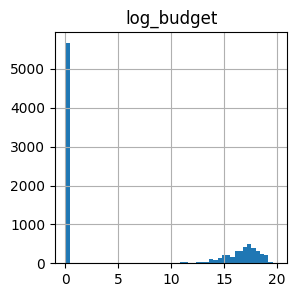

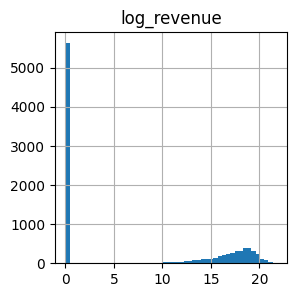

In [1522]:
movies['budget_missing'] = (movies['budget'] == 0).astype(int)
movies['log_budget'] = np.log1p(movies['budget'])

movies[['log_budget']].hist(bins = 50, figsize=(3, 3))

movies['revenue_missing'] = (movies['revenue'] == 0).astype(int)
movies['log_revenue'] = np.log1p(movies['revenue'])

movies[['log_revenue']].hist(bins = 50, figsize=(3, 3))



In [1523]:
movies = movies.drop(columns=['budget'])
movies = movies.drop(columns=['revenue'])

In [1524]:
sc = StandardScaler()
scale_data = sc.fit_transform(movies[['runtime', 'log_budget', 'popularity', 'vote_count', 'vote_average', 'log_revenue']])

In [1525]:
scale_data

array([[-0.57374995, -0.82729334, -0.17261057, -0.34804852,  0.69822792,
        -0.82988764],
       [ 0.72388505,  1.14727311,  1.75539025,  5.84565205,  1.18559904,
         1.55297201],
       [ 0.15616974,  1.40855281,  0.97161871,  5.36691468,  1.01501915,
         1.5754236 ],
       ...,
       [-0.65485214, -0.82729334, -0.23452056, -0.45379603, -2.44841732,
        -0.82988764],
       [-2.54723651, -0.82729334,  0.11760314, -0.45379603, -2.44841732,
        -0.82988764],
       [-2.54723651, -0.82729334, -0.0420936 , -0.45350867, -0.67615867,
        -0.82988764]], shape=(9654, 6))

In [1526]:
scale_df = pd.DataFrame(data=scale_data, columns=['runtime', 'log_budget', 'popularity', 'vote_count', 'vote_average', 'log_revenue'], index=movies.index)
scale_df.head()

,runtime,log_budget,popularity,vote_count,vote_average,log_revenue
id,,,,,,
2,-0.573750,-0.827293,-0.172611,-0.348049,0.698228,-0.829888
11,0.723885,1.147273,1.755390,5.845652,1.185599,1.552972
12,0.156170,1.408553,0.971619,5.366915,1.015019,1.575424
13,1.291600,1.343280,1.708947,7.944510,1.300796,1.537241
14,0.750919,1.185046,0.215060,3.222079,1.096986,1.462447


In [1527]:
movies = movies.drop(columns=['popularity'])
movies = movies.drop(columns=['runtime', 'log_budget', 'vote_count', 'vote_average', 'log_revenue'])
movies = pd.concat([movies, scale_df], axis=1)


In [1528]:
movies.head()

,title,release_date,original_language,genres,year,text,budget_missing,revenue_missing,runtime,log_budget,popularity,vote_count,vote_average,log_revenue
id,,,,,,,,,,,,,,
2,Ariel,1988-10-21,fi,"Drama,Comedy,Crime,Romance",1988,A Finnish man goes to the city to find a job a...,1,1,-0.573750,-0.827293,-0.172611,-0.348049,0.698228,-0.829888
11,Star Wars,1977-05-25,en,"Adventure,Action,Science Fiction",1977,Princess Leia is captured and held hostage by ...,0,0,0.723885,1.147273,1.755390,5.845652,1.185599,1.552972
12,Finding Nemo,2003-05-30,en,"Animation,Family",2003,"Nemo, an adventurous young clownfish, is unexp...",0,0,0.156170,1.408553,0.971619,5.366915,1.015019,1.575424
13,Forrest Gump,1994-06-23,en,"Drama,Comedy,Romance",1994,A man with a low IQ has accomplished great thi...,0,0,1.291600,1.343280,1.708947,7.944510,1.300796,1.537241
14,American Beauty,1999-09-15,en,Drama,1999,"Lester Burnham, a depressed suburban father in...",0,0,0.750919,1.185046,0.215060,3.222079,1.096986,1.462447


In [1529]:
movies['genres'] = movies['genres'].fillna('Unknown')
movies['genres'].value_counts()


genres
Drama                                          1072
Comedy                                          507
Drama,Romance                                   347
Drama,Comedy                                    306
Unknown                                         262
                                               ... 
Fantasy,Horror,Romance                            1
History,Romance,Family                            1
Horror,Action,War                                 1
Adventure,Horror                                  1
Adventure,Fantasy,Drama,Action,Comedy,Music       1
Name: count, Length: 914, dtype: int64

нужно перебрать жанры, тк они смешаны  

In [1530]:
gener_list = movies['genres'].apply(lambda x: x.split(','))
print(gener_list)


id
2               [Drama, Comedy, Crime, Romance]
11         [Adventure, Action, Science Fiction]
12                          [Animation, Family]
13                     [Drama, Comedy, Romance]
14                                      [Drama]
                           ...                 
1618945                       [Comedy, Romance]
1620991                    [Crime, Documentary]
1627792                                 [Drama]
1627796                                 [Drama]
1630155                               [Unknown]
Name: genres, Length: 9654, dtype: object


In [1531]:
mlb = MultiLabelBinarizer()
genres_matrix = csr_matrix(mlb.fit_transform(gener_list))


In [1532]:
movies.head(1)

,title,release_date,original_language,genres,year,text,budget_missing,revenue_missing,runtime,log_budget,popularity,vote_count,vote_average,log_revenue
id,,,,,,,,,,,,,,
2,Ariel,1988-10-21,fi,"Drama,Comedy,Crime,Romance",1988,A Finnish man goes to the city to find a job a...,1,1,-0.57375,-0.827293,-0.172611,-0.348049,0.698228,-0.829888


In [1533]:
top_langs = movies['original_language'].value_counts().head(10).index
movies['language_group'] = movies['original_language'].apply(lambda x: x if x in top_langs else 'other')
top_langs

Index(['en', 'fr', 'ja', 'es', 'de', 'it', 'hi', 'tl', 'ko', 'sv'], dtype='object', name='original_language')

In [1534]:
movies = movies.drop(columns=['original_language'])

In [1535]:
year = movies['year'].copy()
movies['year'] = sc.fit_transform(movies[['year']])
movies['year'].describe()

count    9.654000e+03
mean    -5.193277e-15
std      1.000052e+00
min     -4.609479e+00
25%     -4.048052e-01
50%      3.344780e-01
75%      7.041196e-01
max      1.027556e+00
Name: year, dtype: float64

In [1536]:
movies = movies.drop(columns=['release_date', 'genres'])

In [1537]:
movies.head(1)

,title,year,text,budget_missing,revenue_missing,runtime,log_budget,popularity,vote_count,vote_average,log_revenue,language_group
id,,,,,,,,,,,,
2,Ariel,-0.728242,A Finnish man goes to the city to find a job a...,1,1,-0.57375,-0.827293,-0.172611,-0.348049,0.698228,-0.829888,other


хочу дополнить movie через таблицу reviews забрав оттуда content и movie_id

In [1538]:
reviews = reviews_data[['movie_id', 'content']]
reviews = reviews.set_index(['movie_id'])
reviews = reviews.sort_index()
reviews.head()


,content
movie_id,
11,"(As I'm writing this review, Darth Vader's the..."
11,A long time ago in a childhood not too far awa...
11,Star Wars (1977) is a true masterpiece of cine...
11,A quality start to the franchise.\r\n\r\nI say...
11,Everyone and their mother is going to write re...


In [1539]:
reviews.info()

<class 'pandas.core.frame.DataFrame'>
Index: 13073 entries, 11 to 1608982
Data columns (total 1 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   content  13073 non-null  object
dtypes: object(1)
memory usage: 204.3+ KB


In [1540]:
reviews.index.nunique()

3752

In [1541]:
reviews_per_movie = reviews.groupby(reviews.index).size()
reviews_per_movie.mean()

np.float64(3.484275053304904)

в среднем 3-4 отзыва у фильма

In [1542]:
reviews_text = reviews.groupby(reviews.index)['content'].apply(lambda x : ' '.join(x.head(5)))

есть шум выраженный слешами  I\' и \r\n\r\n

In [1543]:
reviews_text.iloc[0]

'(As I\'m writing this review, Darth Vader\'s theme music begins to build in my mind...)\r\n\r\nWell, it actually has a title, what the Darth Vader theme. And that title is "The Imperial March", composed by the great John Williams, whom, as many of you may already know, also composed the theme music for "Jaws" - that legendary score simply titled, "Main Title (Theme From Jaws)".\r\n\r\nNow, with that lil\' bit of trivia aside, let us procede with the fabled film currently under review: Star Wars. It had been at a drive-in theater in some small Illinois town or other where my mother, my older brother, and I had spent our weekly "Movie Date Night" watching this George Lucas directed cult masterpiece from our car in the parking lot. On the huge outdoor screen, the film appeared to be a silent one, but thanks to an old wire-attached speaker, we were able to hear both the character dialogue and soundtrack loud and clear. We even had ourselves a carful of vittles and snacks - walked back to 

In [1544]:
def clean_text(x):
    x = x.replace("\\'", "'")
    x = x.replace("\r\n", " ")
    x = x.replace("\n", " ")
    return x

In [1545]:
reviews['content'] = reviews['content'].apply(clean_text)

reviews_text = reviews.groupby(reviews.index)['content'].apply(lambda x : ' '.join(x.head(5)))

print(reviews_text.iloc[0])

(As I'm writing this review, Darth Vader's theme music begins to build in my mind...)  Well, it actually has a title, what the Darth Vader theme. And that title is "The Imperial March", composed by the great John Williams, whom, as many of you may already know, also composed the theme music for "Jaws" - that legendary score simply titled, "Main Title (Theme From Jaws)".  Now, with that lil' bit of trivia aside, let us procede with the fabled film currently under review: Star Wars. It had been at a drive-in theater in some small Illinois town or other where my mother, my older brother, and I had spent our weekly "Movie Date Night" watching this George Lucas directed cult masterpiece from our car in the parking lot. On the huge outdoor screen, the film appeared to be a silent one, but thanks to an old wire-attached speaker, we were able to hear both the character dialogue and soundtrack loud and clear. We even had ourselves a carful of vittles and snacks - walked back to our vehicle, of 

In [1546]:
reviews.info()

<class 'pandas.core.frame.DataFrame'>
Index: 13073 entries, 11 to 1608982
Data columns (total 1 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   content  13073 non-null  object
dtypes: object(1)
memory usage: 720.3+ KB


In [1547]:
len(movies)

9654

In [1548]:
movies = movies.merge(right=reviews_text, how='left', left_on='id', right_index=True)
movies.head(3)

,title,year,text,budget_missing,revenue_missing,runtime,log_budget,popularity,vote_count,vote_average,log_revenue,language_group,content
id,,,,,,,,,,,,,
2,Ariel,-0.728242,A Finnish man goes to the city to find a job a...,1,1,-0.573750,-0.827293,-0.172611,-0.348049,0.698228,-0.829888,other,NaN
11,Star Wars,-1.236499,Princess Leia is captured and held hostage by ...,0,0,0.723885,1.147273,1.755390,5.845652,1.185599,1.552972,en,"(As I'm writing this review, Darth Vader's the..."
12,Finding Nemo,-0.035164,"Nemo, an adventurous young clownfish, is unexp...",0,0,0.156170,1.408553,0.971619,5.366915,1.015019,1.575424,en,One of the best animated films I have ever see...


In [1549]:
len(movies)

9654

In [1550]:
movies['review_text'] = movies['content']
movies = movies.drop(columns=['content'])
movies['review_text'] = movies['review_text'].fillna('')

In [1551]:
movies['review_text'].isna().sum()

np.int64(0)

In [1552]:
cast_data = pd.read_csv(r'D:\уник\skillfactory\movies_recomendations\data\cast.csv')
cast_data

,id,movie_id,person_id,name,character,cast_order,movie_title,movie_release_date
0,64660,2,54768,Turo Pajala,Taisto Kasurinen,0,Ariel,1988-10-21
1,64661,2,54769,Susanna Haavisto,Irmeli Pihlaja,1,Ariel,1988-10-21
2,64662,2,4826,Matti Pellonpää,Mikkonen,2,Ariel,1988-10-21
3,64663,2,54770,Eetu Hilkamo,Riku,3,Ariel,1988-10-21
4,64664,2,1177496,Erkki Pajala,Miner,4,Ariel,1988-10-21
...,...,...,...,...,...,...,...,...
150039,73207,1630155,592476,Marian Álvarez,NaN,4,Antes,2026-02-06
150040,73208,1630155,51905,Andrés Gertrúdix,NaN,5,Antes,2026-02-06
150041,73209,1630155,1787126,Pilar Gómez,NaN,6,Antes,2026-02-06
150042,73210,1630155,105161,Emilio Gutiérrez Caba,NaN,7,Antes,2026-02-06


In [1553]:
cast_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150044 entries, 0 to 150043
Data columns (total 8 columns):
 #   Column              Non-Null Count   Dtype 
---  ------              --------------   ----- 
 0   id                  150044 non-null  int64 
 1   movie_id            150044 non-null  int64 
 2   person_id           150044 non-null  int64 
 3   name                150044 non-null  object
 4   character           142822 non-null  object
 5   cast_order          150044 non-null  int64 
 6   movie_title         150044 non-null  object
 7   movie_release_date  149751 non-null  object
dtypes: int64(4), object(4)
memory usage: 9.2+ MB


возьмем фильмы с их главными актерами  

cast_order - это ранжирование актеров по важности, где "0" самый топ

In [1554]:
cast_data['cast_order'].value_counts()

cast_order
0     9662
1     9574
2     9453
3     9305
4     9119
5     8861
6     8590
7     8315
8     8027
9     7703
10    7414
11    7105
12    6800
13    6531
14    6275
15    5967
16    5695
17    5451
18    5215
19    4980
20       2
Name: count, dtype: int64

In [1555]:
cast_top = cast_data[cast_data['cast_order'] < 5]


In [1556]:
cast_top['name_clear'] = cast_top['name'].apply(lambda x: x.replace(" ", '_'))
cast_text = cast_top.groupby('movie_id')['name_clear'].apply(lambda x: " ".join(x))

C:\Users\Aryan\AppData\Local\Temp\ipykernel_4360\3481945975.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  cast_top['name_clear'] = cast_top['name'].apply(lambda x: x.replace(" ", '_'))


In [1557]:
cast_text.head()

movie_id
2     Turo_Pajala Susanna_Haavisto Matti_Pellonpää E...
11    Mark_Hamill Harrison_Ford Carrie_Fisher Peter_...
12    Albert_Brooks Ellen_DeGeneres Alexander_Gould ...
13    Tom_Hanks Robin_Wright Gary_Sinise Sally_Field...
14    Kevin_Spacey Annette_Bening Thora_Birch Wes_Be...
Name: name_clear, dtype: object

добавляем в муви 

In [1558]:
len(movies)

9654

In [1559]:
movies = movies.merge(right=cast_text, how='left', left_on='id', right_index=True)
movies['cast'] = movies['name_clear']

In [1560]:
len(movies)

9654

In [1561]:
movies = movies.drop(columns=['name_clear'])

In [1562]:
movies.head(3)

,title,year,text,budget_missing,revenue_missing,runtime,log_budget,popularity,vote_count,vote_average,log_revenue,language_group,review_text,cast
id,,,,,,,,,,,,,,
2,Ariel,-0.728242,A Finnish man goes to the city to find a job a...,1,1,-0.573750,-0.827293,-0.172611,-0.348049,0.698228,-0.829888,other,,Turo_Pajala Susanna_Haavisto Matti_Pellonpää E...
11,Star Wars,-1.236499,Princess Leia is captured and held hostage by ...,0,0,0.723885,1.147273,1.755390,5.845652,1.185599,1.552972,en,"(As I'm writing this review, Darth Vader's the...",Mark_Hamill Harrison_Ford Carrie_Fisher Peter_...
12,Finding Nemo,-0.035164,"Nemo, an adventurous young clownfish, is unexp...",0,0,0.156170,1.408553,0.971619,5.366915,1.015019,1.575424,en,One of the best animated films I have ever see...,Albert_Brooks Ellen_DeGeneres Alexander_Gould ...


In [1563]:
movies['revenue'] = movies['log_revenue']
movies['budget'] = movies['log_budget']

movies = movies.drop(columns=['log_budget', 'log_revenue'])


In [1564]:
crew = pd.read_csv(r'D:\уник\skillfactory\movies_recomendations\data\crew.csv', engine='python')
crew.head()

,id,movie_id,person_id,name,job,department,movie_title,movie_release_date
0,29930,2,16767,Aki Kaurismäki,Director,Directing,Ariel,1988-10-21
1,29932,2,16767,Aki Kaurismäki,Producer,Production,Ariel,1988-10-21
2,29931,2,16767,Aki Kaurismäki,Writer,Writing,Ariel,1988-10-21
3,1441,11,1,George Lucas,Director,Directing,Star Wars,1977-05-25
4,1438,11,1,George Lucas,Executive Producer,Production,Star Wars,1977-05-25


In [1565]:
crew.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 63632 entries, 0 to 63631
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   id                  63632 non-null  int64 
 1   movie_id            63632 non-null  int64 
 2   person_id           63632 non-null  int64 
 3   name                63632 non-null  object
 4   job                 63632 non-null  object
 5   department          63632 non-null  object
 6   movie_title         63632 non-null  object
 7   movie_release_date  63302 non-null  object
dtypes: int64(3), object(5)
memory usage: 3.9+ MB


In [1566]:
movies.shape

(9654, 14)

In [1567]:
crew['job'].unique()

array(['Director', 'Producer', 'Writer', 'Executive Producer',
       'Screenplay'], dtype=object)

In [1568]:
crew['job'].value_counts()

job
Producer              19750
Executive Producer    18256
Director              10735
Writer                 7823
Screenplay             7068
Name: count, dtype: int64

In [1569]:
crew['department'].unique()

array(['Directing', 'Production', 'Writing'], dtype=object)

In [1570]:
crew['department'].value_counts()

department
Production    38006
Writing       14891
Directing     10735
Name: count, dtype: int64

In [1571]:
crew_per_movie = crew.groupby('movie_id')['job'].nunique()
crew_per_movie.mean()

np.float64(3.281076638586398)

Text(0.5, 1.0, 'Top jobs')

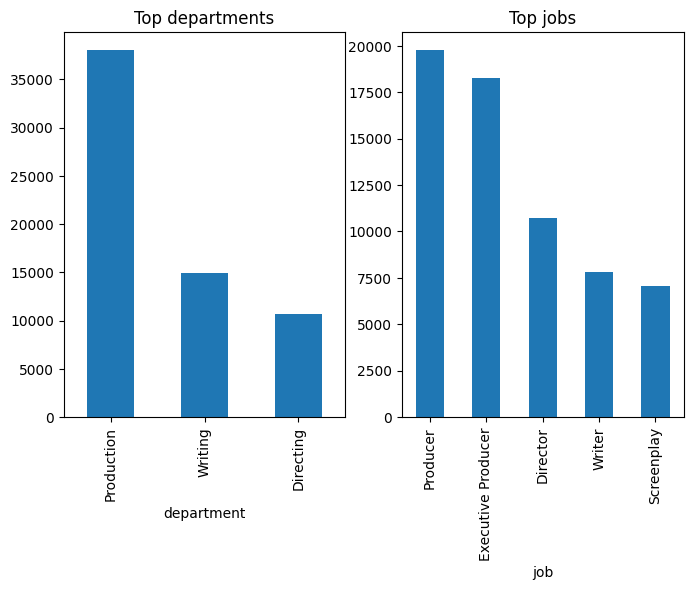

In [1572]:
fig, ax = plt.subplots(1, 2, figsize=(8, 5))

crew['department'].value_counts().head(10).plot(kind='bar', ax=ax[0])
ax[0].set_title('Top departments')

crew['job'].value_counts().head(10).plot(kind='bar', ax=ax[1])
ax[1].set_title('Top jobs')


In [1573]:
crew['name_crew'] = crew['name'].apply(lambda x : x.replace(" ", "_"))
crew_text = crew.groupby('movie_id')['name_crew'].apply(lambda x: " ".join(pd.unique(x)))
crew_text.head()

movie_id
2                                        Aki_Kaurismäki
11                              George_Lucas Gary_Kurtz
12    Andrew_Stanton John_Lasseter Graham_Walters Da...
13    Robert_Zemeckis Wendy_Finerman Steve_Starkey S...
14           Sam_Mendes Dan_Jinks Bruce_Cohen Alan_Ball
Name: name_crew, dtype: object

In [1574]:
movies = movies.merge(right=crew_text, how='left', left_on='id', right_index=True)
movies.head(3)

,title,year,text,budget_missing,revenue_missing,runtime,popularity,vote_count,vote_average,language_group,review_text,cast,revenue,budget,name_crew
id,,,,,,,,,,,,,,,
2,Ariel,-0.728242,A Finnish man goes to the city to find a job a...,1,1,-0.573750,-0.172611,-0.348049,0.698228,other,,Turo_Pajala Susanna_Haavisto Matti_Pellonpää E...,-0.829888,-0.827293,Aki_Kaurismäki
11,Star Wars,-1.236499,Princess Leia is captured and held hostage by ...,0,0,0.723885,1.755390,5.845652,1.185599,en,"(As I'm writing this review, Darth Vader's the...",Mark_Hamill Harrison_Ford Carrie_Fisher Peter_...,1.552972,1.147273,George_Lucas Gary_Kurtz
12,Finding Nemo,-0.035164,"Nemo, an adventurous young clownfish, is unexp...",0,0,0.156170,0.971619,5.366915,1.015019,en,One of the best animated films I have ever see...,Albert_Brooks Ellen_DeGeneres Alexander_Gould ...,1.575424,1.408553,Andrew_Stanton John_Lasseter Graham_Walters Da...


In [1575]:
movies['cast'] = movies['cast'].fillna('')
movies['name_crew'] = movies['name_crew'].fillna('')

In [1576]:
movies.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9654 entries, 2 to 1630155
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   title            9654 non-null   object 
 1   year             9654 non-null   float64
 2   text             9654 non-null   object 
 3   budget_missing   9654 non-null   int64  
 4   revenue_missing  9654 non-null   int64  
 5   runtime          9654 non-null   float64
 6   popularity       9654 non-null   float64
 7   vote_count       9654 non-null   float64
 8   vote_average     9654 non-null   float64
 9   language_group   9654 non-null   object 
 10  review_text      9654 non-null   object 
 11  cast             9654 non-null   object 
 12  revenue          9654 non-null   float64
 13  budget           9654 non-null   float64
 14  name_crew        9654 non-null   object 
dtypes: float64(7), int64(2), object(6)
memory usage: 1.2+ MB


In [1577]:
one = OneHotEncoder()
langs_matrix = one.fit_transform(movies[['language_group']])
movies = movies.drop(columns=['language_group'])

In [1578]:
print(movies.shape[0] == langs_matrix.shape[0])

True


In [1579]:
tfidf_text = TfidfVectorizer(max_features=20000, stop_words='english')
X_text = tfidf_text.fit_transform(movies['text'])

tfidf_reviews = TfidfVectorizer(max_features=20000, stop_words='english')
X_reviews = tfidf_reviews.fit_transform(movies['review_text'])

tfidf_cast = TfidfVectorizer(min_df=2)
X_cast = tfidf_cast.fit_transform(movies['cast'])

tfidf_crew = TfidfVectorizer(min_df=2)
X_crew = tfidf_crew.fit_transform(movies['name_crew'])

num_cols = [
    'year',
    'budget_missing',
    'revenue_missing',
    'runtime',
    'popularity',
    'vote_count',
    'vote_average',
    'revenue',
    'budget'
]

X_num = csr_matrix(movies[num_cols].values)

X = hstack([
    X_text,
    X_reviews,
    X_cast,
    X_crew,
    genres_matrix,
    langs_matrix,
    X_num   
])

In [1595]:
movies['title'].nunique()

9059

искать фильмы будем по названию и году выпуска, тк уникальных названий меньше, чем фильмов 

признак id, по которому собирали фильмы по всем таблицам оставим и вернем старое название movie_id. сделаем reset index чтобы после ввода фильма (тайтл и год выпуска) брать его id и ориентироваться на номер этой строки в X

In [1591]:
movies['movie_id'] = movies.index

поставил movie_id на песто первой колонки

In [1582]:
col = 'movie_id'

movies = movies[[col] + [c for c in movies.columns if c != col]]
movies = movies.reset_index()
movies = movies.drop(columns=['id'])

movies['year_raw'] = year.values
movies[['title', 'year_raw']].head()


movies['title_year'] = (movies['title'].astype(str) + ' (' + movies['year_raw'].astype('Int64').astype(str) + ')')

movies = movies.drop(columns=['year_raw'])

In [1583]:

nn = NearestNeighbors(metric='cosine', algorithm='brute')
nn.fit(X)

,n_neighbors,5
,radius,1.0
,algorithm,'brute'
,leaf_size,30
,metric,'cosine'
,p,2
,metric_params,None
,n_jobs,None


In [1584]:
def recommendation(find, movies, X, top_k, nn):

    find_idx = []
    rec_idx = []

    for movie in find:
        # idx это обьект типа Index, который является массивом
        idx = movies[movies['title_year'].str.lower() == movie.lower()].index
        if len(idx) == 0:
            print('Не найден')
            continue
        else:
            find_idx.append(idx[0])
    
    if len(find_idx) == 0:
        print('Ни один фильм не найден')
        return None

    avg_vector = csr_matrix(X[find_idx].mean(axis=0))

    # оба 2D
    distances, indices = nn.kneighbors(X=avg_vector, n_neighbors=top_k)

    # indices[0] для того, чтобы сделать из 2Д 1Д
    rec_idx = [i for i in indices[0] if i not in find_idx][:top_k]
    return movies.iloc[rec_idx][['title_year']]

проверка фильмов на космическую фантастику

In [1585]:
find = ['Star Wars (1977)', 'Alien (1979)', 'The Empire Strikes Back (1980)']
recs = recommendation(find, movies, X, 10, nn)
recs

,title_year
518,Return of the Jedi (1983)
228,The Matrix (1999)
44,Back to the Future (1985)
2005,Inception (2010)
498,Iron Man (2008)
3905,Star Wars: The Force Awakens (2015)
4919,Avengers: Infinity War (2018)


In [1586]:
find = [
    'Titanic (1997)',
    'The Notebook (2004)',
    'Pride & Prejudice (2005)'
]
recs = recommendation(find, movies, X, 10, nn)
recs

,title_year
3,Forrest Gump (1994)
3060,Django Unchained (2012)
3614,The Wolf of Wall Street (2013)
3946,Interstellar (2014)
118,The Shawshank Redemption (1994)
5030,La La Land (2016)
200,Fight Club (1999)
4255,Gone Girl (2014)


In [1587]:
find = [
    'The Notebook (2004)',
    'A Walk to Remember (2002)',
    'The Fault in Our Stars (2014)'
]

recs = recommendation(find, movies, X, 10, nn)
recs

,title_year
4893,Me Before You (2016)
2987,The Great Gatsby (2013)
175,A Beautiful Mind (2001)
5652,Call Me by Your Name (2017)
5030,La La Land (2016)
1441,Slumdog Millionaire (2008)
4685,The Theory of Everything (2014)
3934,Her (2013)


In [1588]:
find = [
    'Before Sunrise (1995)',
    'Before Sunset (2004)',
    'Blue Valentine (2010)'
]

recs = recommendation(find, movies, X, 10, nn)
recs

Не найден


,title_year
64,Brokeback Mountain (2005)
6570,Five Feet Apart (2019)
3249,The Lucky One (2012)
689,Atonement (2007)
1153,A Walk to Remember (2002)
5286,Collateral Beauty (2016)
4386,The Longest Ride (2015)
3144,The Vow (2012)
